In [12]:
import numpy as np
import pandas as pd
import os
from glob import glob
import json
from datetime import datetime

In [530]:
arr = []
files = glob(os.path.join('json', '*.json'))

for file in files:
  if ("Streaming_History_Audio" in file):  
    with open (file, 'r') as f:
      try:
        contents = json.load(f)
        arr.extend(contents)
      except Exception as e:
        print(e)

# TODO: gist this (select key as k from table... translated to py)
select = [('ts','ts'), ('ms_played', 'ms_played'), ('reason_start', 'reason_start'), 
  ('reason_end', 'reason_end'), 
  ('master_metadata_track_name', 'track'), ('master_metadata_album_artist_name', 'artist'),
  ('master_metadata_album_album_name', 'album'), ('spotify_track_uri','uri'), ('conn_country', 'conn_country')]
# data = np.array([{k[1]: i[k[0]] for k in select} for i in arr])

data = np.array([[i[k[0]] for k in select] for i in arr])
df = pd.DataFrame(data)
df.columns = [k[1] for k in select]
streams = df[df['ms_played'] >= 30000].copy()
streams['ts'] = pd.to_datetime(streams['ts']).dt.tz_convert('America/Vancouver')

streams = streams.set_index('ts').sort_index()
streams['date'] = streams.index.strftime('%Y-%m-%d')

streams.to_csv('csv/streams.csv')

dated_streams = streams.loc["2025"]

In [278]:
monthly_top_artists = pd.DataFrame([])
months = pd.period_range(start="2018-01", end=streams.index[-1].strftime('%Y-%m'), freq='M')

for m in months:
  pivot_table = streams.loc[m.strftime('%Y-%m')].pivot_table(
      index='artist',
      values=['ms_played'],
      aggfunc={'ms_played':'sum'},
  ).sort_values(by='ms_played',ascending=False).head(50)
  monthly_top_artists[m] = pd.Series(pivot_table.index)

monthly_top_artists.index = list(range(1,51))
monthly_top_artists.to_csv('csv/monthly_top_artists.csv')

top_artists_pos = {}
for m, c in monthly_top_artists.iteritems():
  for index, artist in c.items():
    if artist not in top_artists_pos:
      top_artists_pos[artist] = {}
    top_artists_pos[artist][m.strftime('%Y-%m')] = index

top_artists_pos = pd.DataFrame.from_dict(top_artists_pos, orient='index').filter(like="2025").loc[(test <= 10).any(axis=1)]
top_artists_pos.to_csv('csv/top_artists_pos.csv')

In [211]:
# should have dated_streams = streams.loc[x] higher up here

top_artists = dated_streams.pivot_table(
    index='artist',
    values=['ms_played', 'uri', 'track', 'date'],
    aggfunc={'ms_played':'sum', 'uri': 'count', 'track': 'nunique', 'date': 'nunique'},
).sort_values(by='ms_played',ascending=False).head(50)
top_artists['h'] = round(top_artists['ms_played'] / 1000 / 60 / 60, 1)
top_artists.to_csv('csv/top_artists.csv')

top_albums = dated_streams.pivot_table(
    index='album',
    values=['ms_played', 'uri', 'date'],
    aggfunc={'ms_played':'sum', 'uri': 'count', 'date': 'nunique'},
).sort_values(by='ms_played',ascending=False).head(50)
top_albums['h'] = round(top_albums['ms_played'] / 1000 / 60 / 60, 1)
top_albums.to_csv('csv/top_albums.csv')

top_tracks = dated_streams.pivot_table(
    index='track',
    values=['ms_played', 'uri', 'date'],
    aggfunc={'ms_played':'sum', 'uri': 'count', 'date': 'nunique'},
).sort_values(by='ms_played',ascending=False).head(50)
top_tracks['h'] = round(top_tracks['ms_played'] / 1000 / 60 / 60, 1)
top_tracks.to_csv('csv/top_tracks.csv')

In [230]:
skips = df[(df['ms_played'] < 30000) & (df['reason_end'] == "fwdbtn")].copy()
skips['ts'] = pd.to_datetime(skips['ts'])
skips = skips.set_index('ts').sort_index()
skips['date'] = skips.index.strftime('%Y-%m-%d')

top_skips = skips.loc['2025'].pivot_table(
    index='track',
    values=['ms_played', 'uri', 'date'],
    aggfunc={'ms_played':'sum', 'uri': 'count', 'date': 'nunique'},
).sort_values(by='uri',ascending=False).head(50)

# top_skips

In [245]:
streams.agg({"ms_played": "sum", "uri": "count", "artist": "nunique", "track": "nunique"})

df["ms_played"].sum()

11454297633

In [364]:
tod_matrix = [{} for i in range(7)]
for d in range(7):
  for t in ["early morning", "morning", "midday", "afternoon", "evening", "night", "late night"]:
    tod_matrix[d][t] = 0

for ts, ms_played in zip(dated_streams.index, dated_streams["ms_played"]):
  tod = "late night"
  if ts.hour < 6: tod = "early morning"
  elif ts.hour < 10: tod = "morning"
  elif ts.hour < 13: tod = "midday"
  elif ts.hour < 16: tod = "afternoon"
  elif ts.hour < 19: tod = "evening"
  elif ts.hour < 22: tod = "night"
  tod_matrix[ts.day_of_week][tod] += ms_played

tod_matrix = pd.DataFrame(tod_matrix)
tod_matrix.index = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
tod_matrix = tod_matrix.T / 1000 / 60 / 60
tod_matrix.insert(loc=0, column='Range', value=["12AM-06AM", "06AM-10AM", "10AM-01PM", "01PM-04PM", "04PM-07PM", "07PM-10PM", "10PM-12PM"])

tod_matrix.to_csv('csv/tod_matrix.csv')

hour_matrix = [[0 for j in range(24)] for i in range (7)]
for ts, ms_played in zip(dated_streams.index, dated_streams["ms_played"]):
  hour_matrix[ts.day_of_week][ts.hour] += ms_played

hour_matrix = pd.DataFrame(hour_matrix) / 1000 / 60 / 60
hour_matrix.index = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hour_matrix.to_csv('csv/hour_matrix.csv')

day_matrix = [[0 for j in range(53)] for i in range(7)]
for ts, ms_played in zip(dated_streams.index, dated_streams["ms_played"]):
  year, week, day = ts.isocalendar()
  if (year > 2025): week = 53
  day_matrix[day-1][week-1] += ms_played

day_matrix = pd.DataFrame(day_matrix) / 1000 / 60 / 60
day_matrix.to_csv('csv/day_matrix.csv')

In [390]:
mask = (dated_streams["artist"].isin(top_artists.head(5).index)) & (dated_streams['reason_start'] != "appload")
top_five = dated_streams[mask].pivot_table(
    index=['artist','track'],
    values=['uri'],
    aggfunc={'uri': 'count'}
).sort_values(by='uri',ascending=False).head(50)

top_five = top_five.groupby('artist').apply(lambda x: x.nlargest(5, 'uri'))
top_five.to_csv('csv/top_five.csv')

In [521]:
single_day_streams = dated_streams[dated_streams["reason_end"] == "trackdone"].copy()
single_day_streams["date"] = single_day_streams.index.date
single_day_streams = single_day_streams.pivot_table(
    index=['artist','track', 'date'],
    values=['uri'],
    aggfunc={'uri': 'count'}
).sort_values(by=['track', 'date']).reset_index()

streaks = {}
for track, date in zip(single_day_streams["track"], single_day_streams["date"]):
  if (track not in streaks): streaks[track] = {}
  if (date not in streaks[track]): streaks[track][date] = 1

  yesterday = date-pd.Timedelta(days=1)
  if (yesterday in streaks[track]):
    streaks[track][date] = streaks[track][yesterday] + 1

reformed_data = {
    (outer_key, inner_key): value
    for outer_key, inner_dict in streaks.items()
    for inner_key, value in inner_dict.items()
}

streaks = pd.DataFrame.from_dict(reformed_data, orient='index', columns=["streak"]).sort_values(by="streak", ascending=False)
streaks = streaks[streaks['streak'] >= 5]
streaks.to_csv('csv/streaks.csv')

single_day_streams = single_day_streams[single_day_streams["uri"] >= 5]
single_day_streams.to_csv('csv/single_day_streams.csv')


In [529]:
countries = streams.pivot_table(
    index='conn_country',
    values=['ms_played', 'uri', 'track'],
    aggfunc={'ms_played':'sum', 'uri': 'count'},
).sort_values(by='ms_played',ascending=False)
countries['h'] = countries['ms_played'] / 1000 / 60 / 60
# countries

In [552]:
monthly_stats = streams[streams["reason_start"] != "appload"]
monthly_stats = monthly_stats.groupby(monthly_stats.index.strftime('%Y-%m')).agg({'ms_played': 'sum', 'uri': 'count', 'track': 'nunique', 'artist': 'nunique'})
monthly_stats.to_csv('csv/monthly_stats.csv')

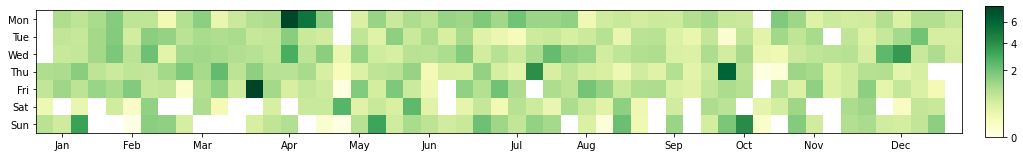

In [102]:
# imports for plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
from copy import copy
from matplotlib.colors import PowerNorm

day_matrix = pd.read_csv("./csv/day_matrix.csv", index_col=0)
day_matrix.replace(0, np.nan, inplace=True)

cmap = copy(mpl.cm.get_cmap("YlGn"))
cmap.set_bad(color="white")

plt.imshow(day_matrix, cmap=cmap, norm=PowerNorm(gamma=0.5))

plt.rcParams["figure.figsize"] = (20,6)

ms = pd.date_range(start="2025-01", end="2025-12", freq='MS')
plt.xticks(ms.isocalendar()['week'],ms.strftime('%b'))
plt.yticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
cbar = plt.colorbar(shrink=0.4, pad=0.02, aspect=7)
plt.gcf().set_facecolor("white")

plt.show()
# day_matrix


In [16]:
concerts_2025 = [
  "mac demarco victoria", "lorde seattle",
  "peach pit victoria", "tyler vancouver",
  "beach boys victoria", "beabadoobee vancouver"
]

playlists = []
with open('json/Playlist1.json', 'r') as file:
  playlists = json.load(file)["playlists"]

playlists = [p for p in playlists if p["name"] in concerts_2025]

sum(len(p["items"]) for p in playlists)

173

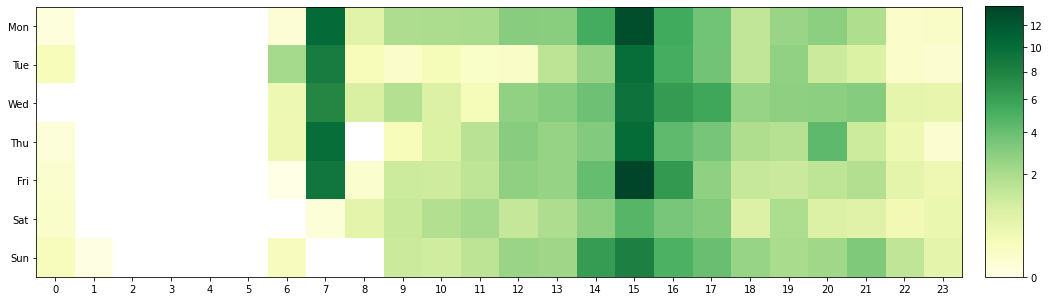

('15', 69.01087166666667)
('Monday', 58.78946583333334)


In [153]:
hour_matrix = pd.read_csv("./csv/hour_matrix.csv", index_col=0)

hour_matrix.replace(0, np.nan, inplace=True)

cmap = copy(mpl.cm.get_cmap("YlGn"))
cmap.set_bad(color="white")

plt.imshow(hour_matrix, cmap=cmap, norm=PowerNorm(gamma=0.5))

plt.rcParams["figure.figsize"] = (20,6)

plt.xticks(range(24))
plt.yticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
cbar = plt.colorbar(shrink=0.83, pad=0.02, aspect=7)

plt.gcf().set_facecolor("white")
plt.show()

# TODO: move
def max_sum(matrx, axis=0):
  axis_max = matrx.sum(axis=axis).idxmax()
  sum_value = matrx.sum(axis=axis)[axis_max]
  return axis_max, sum_value

print(max_sum(hour_matrix))
print(max_sum(hour_matrix, axis=1))

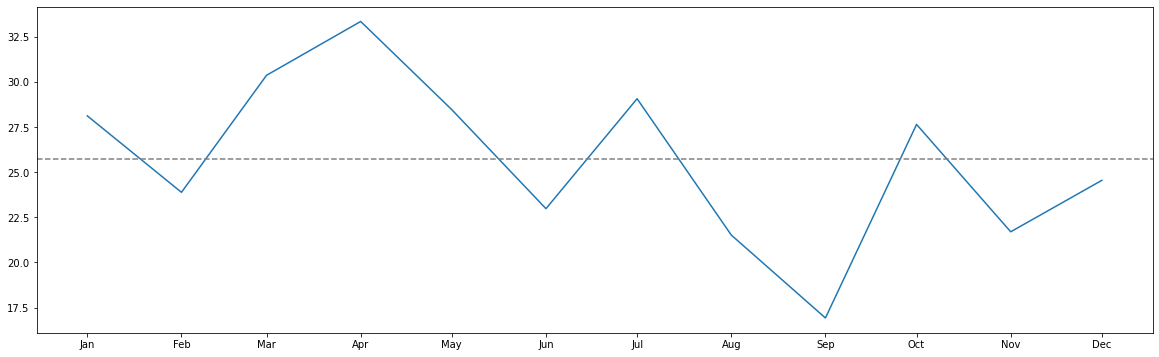

In [201]:
monthy_mins = pd.read_csv("./csv/monthly_stats.csv", index_col=0).reset_index()
monthy_mins['ts'] = pd.to_datetime(monthy_mins['ts'])
monthy_mins = monthy_mins.set_index('ts').sort_index() 
this_year = monthy_mins.loc["2025"]["ms_played"] / 1000 / 60 / 60
last_year = monthy_mins.loc["2024"]["ms_played"] / 1000 / 60 / 60

fig, ax = plt.subplots()
ax.plot(this_year)
# ax.plot(this_year.index, last_year, color='lightblue')
plt.axhline(y=this_year.mean(), color='grey', linestyle='--')

ax.set_xticks(this_year.index, ms.strftime('%b'))
plt.gcf().set_facecolor("white")
plt.show()


In [202]:
ax.plot(this_year.index, last_year, color='lightblue')
plt.show()